In [ ]:
# FSDL Lab 4 | Experiment Management with Weights & Biases


!pip install wandb pytorch-lightning --quiet

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import pytorch_lightning as pl
import wandb
from pytorch_lightning.loggers import WandbLogger
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 63.7 MB/s eta 0:00:00
PyTorch: 2.10.0+cu128
Device: cuda


In [ ]:
# Sign up free at wandb.ai then paste your API key when prompted
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: omarfarooqq957 (omarfarooqq957-punjab-information-technology-board) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.EMNIST(
    root='./data', split='letters',
    train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.EMNIST(
    root='./data', split='letters',
    train=False, download=True, transform=transform
)

num_classes = 26
print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")

100%|██████████| 562M/562M [00:06<00:00, 84.4MB/s]


Train: 124800 | Test: 20800


In [ ]:
class TrackedCNN(pl.LightningModule):
    def __init__(self, lr=1e-3, dropout=0.3, hidden_dim=256):
        super().__init__()
        self.lr = lr
        self.save_hyperparameters()

        self.conv_block = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, x):
        return self.classifier(self.conv_block(x))

    def training_step(self, batch, batch_idx):
        x, y = batch
        y = y - 1
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = (logits.argmax(1) == y).float().mean()
        self.log('train_loss', loss, prog_bar=True, on_epoch=True)
        self.log('train_acc', acc, prog_bar=True, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y = y - 1
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = (logits.argmax(1) == y).float().mean()
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', acc, prog_bar=True)

    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=self.lr)

print("Model defined.")

Model defined.


In [ ]:
# Experiment 1 — baseline config
config_1 = dict(lr=1e-3, dropout=0.3, hidden_dim=256, epochs=5, batch_size=64)

wandb_logger_1 = WandbLogger(project="FSDL_EMNIST", name="baseline", config=config_1)

train_loader = DataLoader(train_dataset, batch_size=config_1['batch_size'], shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=config_1['batch_size'], shuffle=False, num_workers=2)

model_1 = TrackedCNN(lr=config_1['lr'], dropout=config_1['dropout'], hidden_dim=config_1['hidden_dim'])

trainer_1 = pl.Trainer(
    max_epochs=config_1['epochs'],
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1,
    logger=wandb_logger_1,
    enable_checkpointing=False,
    enable_progress_bar=True
)

trainer_1.fit(model_1, train_loader, test_loader)
wandb.finish()
print("Experiment 1 complete.")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ conv_block │ Sequential       │ 18.8 K │ train │     0 │
│ 1 │ classifier │ Sequential       │  809 K │ train │     0 │
│ 2 │ criterion  │ CrossEntropyLoss │      0 │ train │     0 │
└───┴────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 828 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 828 K                                                                                                
Total estimated model params size (MB): 3                                                                          
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


epoch,▁▁▁▁▁▁▁▁▁▃▃▃▃▃▃▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▆▆██████
train_acc_epoch,▁▆▇██
train_acc_step,▁▅▁▆▂▃▅▅▇▅▇▃▆▅▇▆▅▆▇▅▅▅▅▆▆▆▅▅▄▆█▆▇█▆▆▇▇▅▄
train_loss_epoch,█▃▂▁▁
train_loss_step,█▄▂▃▂▄▂▂▂▂▁▂▂▂▂▁▂▂▂▁▂▁▂▂▂▂▁▂▁▂▁▂▂▁▁▁▃▂▁▁
trainer/global_step,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇██
val_acc,▁▄▇██
val_loss,█▄▂▁▁
epoch,4
train_acc_epoch,0.94245
train_acc_step,0.89062


Experiment 1 complete.


In [ ]:
# Experiment 2 — tweak learning rate, see how it affects results
config_2 = dict(lr=1e-2, dropout=0.3, hidden_dim=256, epochs=5, batch_size=64)

wandb_logger_2 = WandbLogger(project="FSDL_EMNIST", name="high_lr", config=config_2)

model_2 = TrackedCNN(lr=config_2['lr'], dropout=config_2['dropout'], hidden_dim=config_2['hidden_dim'])

trainer_2 = pl.Trainer(
    max_epochs=config_2['epochs'],
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1,
    logger=wandb_logger_2,
    enable_checkpointing=False,
    enable_progress_bar=True
)

trainer_2.fit(model_2, train_loader, test_loader)
wandb.finish()
print("Experiment 2 complete.")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ conv_block │ Sequential       │ 18.8 K │ train │     0 │
│ 1 │ classifier │ Sequential       │  809 K │ train │     0 │
│ 2 │ criterion  │ CrossEntropyLoss │      0 │ train │     0 │
└───┴────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 828 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 828 K                                                                                                
Total estimated model params size (MB): 3                                                                          
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


epoch,▁▁▁▁▁▁▁▁▁▁▃▃▃▃▃▃▃▃▃▃▅▅▅▅▅▅▅▅▆▆▆▆▆▆▆█████
train_acc_epoch,▄▁█▃▄
train_acc_step,▃▃▄▅▁▂▅▅▂▄▃▇▄▂▂▆▆▁▂▃▃▂█▃▂▃▅▃▃▁▂▆▃▄▁▃▃▅▁▄
train_loss_epoch,█▁▁▁▁
train_loss_step,▄▃▅▅▆▂▅▄▄▄▃▆▆▅▇▇▄▃▁▆▃▄█▄█▅█▆▄▅▅▅▅▅▂▄▃▃█▅
trainer/global_step,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇████
val_acc,▁▁▁▁▁
val_loss,█▂▂▁▂
epoch,4
train_acc_epoch,0.03813
train_acc_step,0.04688


Experiment 2 complete.


In [ ]:
# Experiment 3 — more regularization
config_3 = dict(lr=1e-3, dropout=0.5, hidden_dim=256, epochs=5, batch_size=64)

wandb_logger_3 = WandbLogger(project="FSDL_EMNIST", name="high_dropout", config=config_3)

model_3 = TrackedCNN(lr=config_3['lr'], dropout=config_3['dropout'], hidden_dim=config_3['hidden_dim'])

trainer_3 = pl.Trainer(
    max_epochs=config_3['epochs'],
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1,
    logger=wandb_logger_3,
    enable_checkpointing=False,
    enable_progress_bar=True
)

trainer_3.fit(model_3, train_loader, test_loader)
wandb.finish()
print("Experiment 3 complete.")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ conv_block │ Sequential       │ 18.8 K │ train │     0 │
│ 1 │ classifier │ Sequential       │  809 K │ train │     0 │
│ 2 │ criterion  │ CrossEntropyLoss │      0 │ train │     0 │
└───┴────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 828 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 828 K                                                                                                
Total estimated model params size (MB): 3                                                                          
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


epoch,▁▁▁▁▁▁▁▁▁▁▃▃▃▃▃▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▆█████████
train_acc_epoch,▁▆▇██
train_acc_step,▂▄▁▅▇▄▅▄▄█▅▄▆▇▆▅▆▆██▇▆█▇▇▇▇███▄█▇█▇███▆▆
train_loss_epoch,█▃▂▁▁
train_loss_step,█▅▅▃▅▄▄▃▃▂▃▂▃▃▂▁▂▂▂▂▂▁▂▂▁▁▁▂▁▃▁▂▁▂▂▁▁▃▁▁
trainer/global_step,▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▄▄▅▅▅▅▅▅▅▅▅▆▆▆▇▇▇▇███
val_acc,▁▄▇▇█
val_loss,█▅▂▂▁
epoch,4
train_acc_epoch,0.92983
train_acc_step,0.85938


Experiment 3 complete.


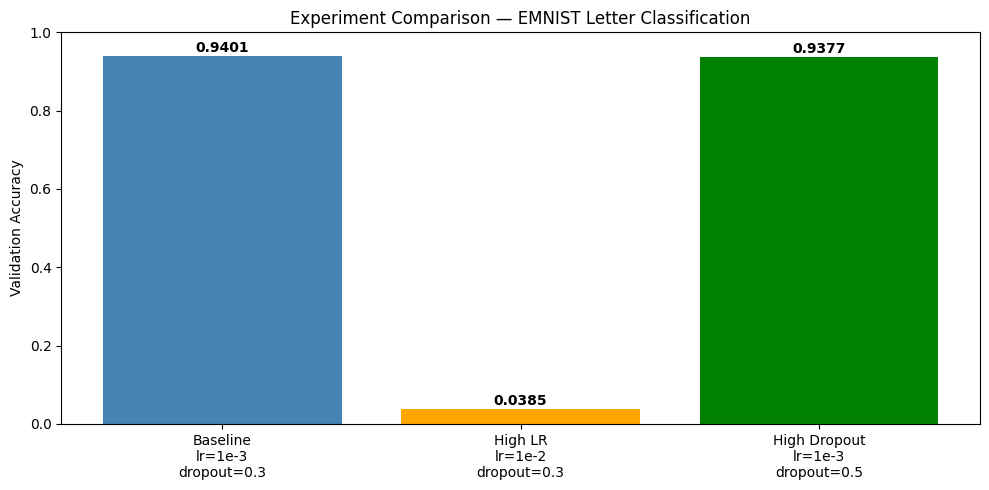


Best config: Baseline
lr=1e-3
dropout=0.3
Best accuracy: 0.9401


In [ ]:
def get_val_acc(trainer, loader, model):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            y = y - 1
            logits = model(x)
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)
    return correct / total

acc1 = get_val_acc(trainer_1, test_loader, model_1)
acc2 = get_val_acc(trainer_2, test_loader, model_2)
acc3 = get_val_acc(trainer_3, test_loader, model_3)

experiments = ['Baseline\nlr=1e-3\ndropout=0.3',
               'High LR\nlr=1e-2\ndropout=0.3',
               'High Dropout\nlr=1e-3\ndropout=0.5']
accs = [acc1, acc2, acc3]

plt.figure(figsize=(10, 5))
bars = plt.bar(experiments, accs, color=['steelblue', 'orange', 'green'])
plt.title("Experiment Comparison — EMNIST Letter Classification")
plt.ylabel("Validation Accuracy")
plt.ylim(0, 1)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.01,
             f"{acc:.4f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nBest config: {experiments[np.argmax(accs)]}")
print(f"Best accuracy: {max(accs):.4f}")



# FSDL Lab 4 Recap — Experiment Management with W&B

## What We Built
A full experiment management workflow using Weights & Biases to track,
compare, and analyze 3 training runs on EMNIST letter classification —
mirroring FSDL's W&B workflow on their text recognizer.

## The Process
1. Logged into W&B and created a project (FSDL_EMNIST)
2. Defined a configurable CNN model inside PyTorch Lightning
3. Run 1 — Baseline: lr=1e-3, dropout=0.3
4. Run 2 — Higher LR: lr=1e-2, dropout=0.3
5. Run 3 — Higher Dropout: lr=1e-3, dropout=0.5
6. Each run automatically logged to W&B dashboard
7. Compared all 3 runs locally with a bar chart

## Key Concepts Practiced
- WandbLogger integration with PyTorch Lightning
- Logging hyperparameters, losses, and metrics per run
- Systematic hyperparameter comparison
- Identifying best config from multiple experiments

## Why Experiment Management Matters
Without tracking, you lose which config produced which result.
W&B gives you a full history of every run — metrics, hyperparams,
system stats — so you can reproduce and build on your best results.